In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

: 

In [ ]:
from pointcloud.config_varients import caloclouds_3_S2P_withincell, caloclouds_3_S2P_steps, caloclouds_3_S2P_hdbscan
from pointcloud.models.load import load_flow_model, load_diffusion_model
from pointcloud.utils.gen_utils import gen_cond_showers_batch
from pointcloud.utils.metadata import Metadata
from pointcloud.utils.detector_map import floors_ceilings
from pointcloud.data.conditioning import read_raw_regaxes_withcond

/eos/user/m/mamozzan/CaloClouds-3/caloclouds3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# USER INPUT !!!
data_used = "withincell" # options: [withincell, steps, hdbscan] 

In [ ]:
if data_used == "withincell":
    config = caloclouds_3_S2P_withincell.Configs()
elif data_used == "hdbscan":
    config = caloclouds_3_S2P_hdbscan.Configs()
elif data_used == "steps":
    config = caloclouds_3_S2P_steps.Configs()
else:
    print("insert a valid type of data")
config.device = 'cuda 'if torch.cuda.is_available() else 'cpu'

In [ ]:
if data_used == "withincell":
    shower_flow_path = "/eos/user/m/mamozzan/point-cloud-diffusion-data/showerFlow/input_cc3_withincell/ShowerFlow_alt1_nb2_inputs1152921504606846975_fnorms_best.pth"
    model_path = "/eos/user/m/mamozzan/CaloClouds-3/log_dir/CD_S2P_WithinCell_2026_06_10__15_05_47/ckpt_0.000000_10000000.pt"
    _sf_dir = "/eos/user/m/mamozzan/point-cloud-diffusion-data/showerFlow/input_cc3_withincell"
elif data_used == "hdbscan":
    shower_flow_path = "/eos/user/m/mamozzan/point-cloud-diffusion-data/showerFlow/input_cc3_hdbscan/ShowerFlow_alt1_nb2_inputs1152921504606846975_fnorms_best.pth"
    model_path = "/eos/user/m/mamozzan/CaloClouds-3/log_dir/CD_S2P_HDBScan_2026_06_10__15_07_21/ckpt_0.000000_10000000.pt"
    _sf_dir = "/eos/user/m/mamozzan/point-cloud-diffusion-data/showerFlow/input_cc3_hdbscan"
elif data_used == "steps":
    shower_flow_path = "/eos/user/m/mamozzan/point-cloud-diffusion-data/showerFlow/input_cc3_identity/ShowerFlow_alt1_nb2_inputs1152921504606846975_fnorms_best.pth"
    model_path = "/eos/user/m/mamozzan/CaloClouds-3/log_dir/CD_S2P_Steps_2026_06_05__14_26_09/ckpt_0.000000_10000000.pt"
    _sf_dir = "/eos/user/m/mamozzan/point-cloud-diffusion-data/showerFlow/input_cc3_identity"

In [ ]:
flow, distribution, transforms = load_flow_model(config, shower_flow_path)

# Load the per-layer normalisers saved during shower flow training.
# The standard showerflow_dir lookup uses "input_cc3" but the model lives in
# "input_cc3_withincell", so we point directly at the training folder.

_input_norms = np.load(f"{_sf_dir}/input_norms.npz")
config.shower_flow_clusters_per_layer_norm = float(_input_norms["clusters_per_layer_norm"])
config.shower_flow_energy_per_layer_norm   = float(_input_norms["energy_per_layer_norm"])
print(f"Shower flow loaded.  clusters_norm={config.shower_flow_clusters_per_layer_norm:.4f}  energy_norm={config.shower_flow_energy_per_layer_norm:.4f}")

Shower flow loaded.  clusters_norm=0.0120  energy_norm=8.9384


In [ ]:
model, _, _, _ = load_diffusion_model(config, "Diffusion", model_path)

# Set to True to apply the polynomial cluster-count scaling computed in calculate_coef.ipynb.
# Set to False to skip all scaling (useful for debugging shower flow output directly).
apply_n_scaling = False

config.shower_flow_n_scaling = apply_n_scaling
if apply_n_scaling:
    # these are the old ones from Henry's model
    config.shower_flow_coef_real = np.array([ 2.66430185e-09, -3.19668816e-05,  3.53275061e-01,  4.65393214e+01])
    config.shower_flow_coef_fake = np.array([-7.49377548e-07,  2.69954466e-03, -2.35388812e-03,  4.42644615e+02])
    config.shower_flow_n_splines = None

print(f"Diffusion model loaded.  (cluster scaling: {apply_n_scaling})")

Diffusion model loaded.  (cluster scaling: False)


In [ ]:
# Load real events first — then reuse their conditioning to drive generation,
# so both samples share the same energy/angle distribution.
n_showers = 5000
conds_real, real_events = read_raw_regaxes_withcond(
    config, total_size=n_showers, for_model="diffusion"
)
real_events = np.array(real_events)  # (n_showers, max_points, 4)
cond = torch.tensor(np.array(conds_real)).float().to(config.device)  # (n_showers, 4)
if len(cond.shape) == 1:
    cond = cond.unsqueeze(-1)

# The generation pipeline calibrates hit energies to MeV
# (vis_eng_rescale × gev_to_mev in showerflow_utils / gen_v1_inner_batch).
# Real h5 energies are stored in units of GeV/vis_eng_rescale — rescale here
# so both datasets share the same axis.
meta = Metadata(config)
real_events = real_events.copy()
real_events[:, :, 3] *= meta.vis_eng_rescale * 1000  # h5 energy units → MeV

print(f"Real events shape:   {real_events.shape}")
print(f"Conditioning shape:  {cond.shape}  —  [energy, px, py, pz] from the real dataset")

Selecting evenly spaced events
Real events shape:   (5000, 2499, 4)
Conditioning shape:  torch.Size([5000, 4])  —  [energy, px, py, pz] from the real dataset


In [ ]:
with torch.no_grad():
    fake_showers = gen_cond_showers_batch(
        model,
        distribution,
        cond,
        bs=32,
        config=config,
    )

print(f"Generated showers shape: {fake_showers.shape}")
# fake_showers: (n_showers, max_points, 4)  —  columns are (x, y, z, energy)
# padded hits have energy <= 0

/eos/home-m/mamozzan/CaloClouds-3/scripts/plotting/pointcloud/utils/gen_utils.py:472: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cond = torch.tensor(cond).to(config.device).float()
/eos/home-m/mamozzan/CaloClouds-3/scripts/plotting/pointcloud/utils/gen_utils.py:135: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cond_feats = torch.tensor(cond_feats).float()


Generated showers shape: (5000, 3000, 4)


## Hit-level coordinate distributions: generated vs real

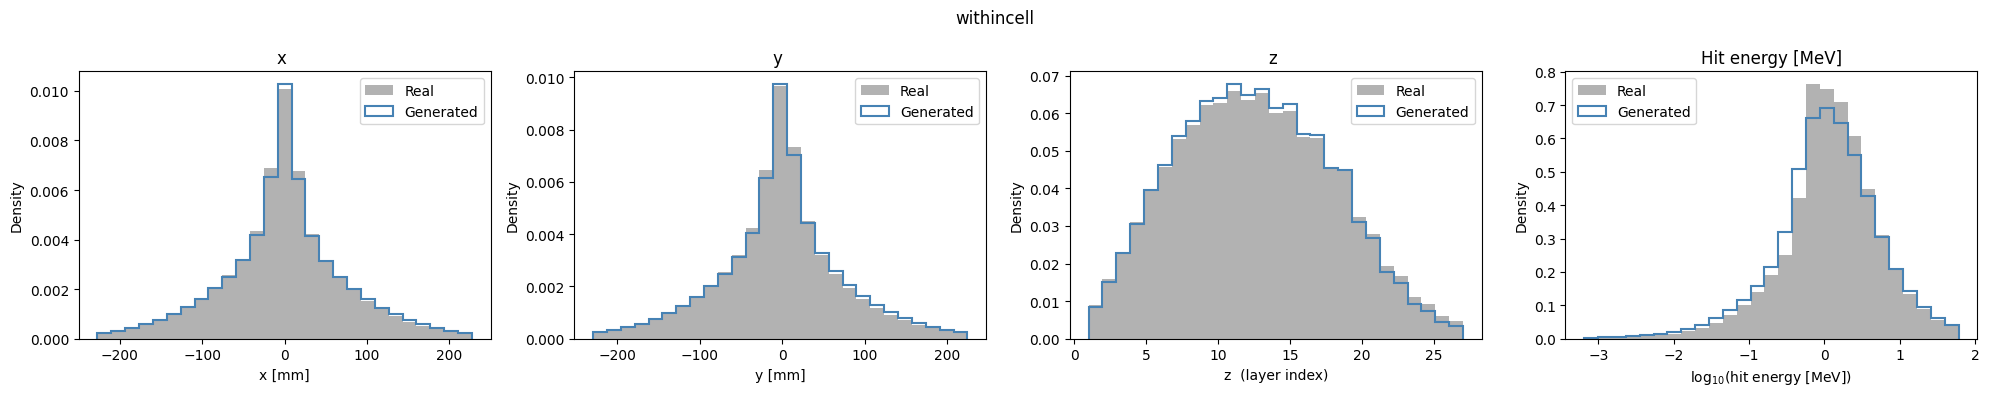

In [ ]:
gen_mask  = fake_showers[:, :, 3] > 0
real_mask = real_events[:, :, 3] > 0

# meta is already defined in cell-load-real
layer_mid_global = meta.layer_bottom_pos_global + meta.cell_thickness_global / 2

# --- z: convert generated (global mm) → layer index; floor real z to integer layer ---
gen_z_layer  = np.abs(fake_showers[:, :, 2][:, :, None] - layer_mid_global).argmin(axis=2)
real_z_layer = np.floor(real_events[:, :, 2]).astype(int).clip(0, len(layer_mid_global) - 1)

gen_zs  = gen_z_layer[gen_mask].astype(float)
real_zs = real_z_layer[real_mask].astype(float)

real_xs, real_ys = real_events[:,:,0][real_mask], real_events[:,:,1][real_mask]
gen_xs,  gen_ys  = fake_showers[:,:,0][gen_mask], fake_showers[:,:,1][gen_mask]

real_es = real_events[:, :, 3][real_mask]
gen_es  = fake_showers[:, :, 3][gen_mask]

# --- Plot ---
labels    = ['x [mm]', 'y [mm]','z  (layer index)', 'log$_{10}$(hit energy [MeV])']
gen_vals  = [gen_xs,  gen_ys,  gen_zs,  np.log10(gen_es.clip(1e-6))]
real_vals = [real_xs, real_ys, real_zs, np.log10(real_es.clip(1e-6))]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, label, gv, rv in zip(axes, labels, gen_vals, real_vals):
    lo = min(np.percentile(gv, 1), np.percentile(rv, 1))
    hi = max(np.percentile(gv, 99), np.percentile(rv, 99))
    n_bins = 60 if labels!='z  (layer index)' else hi-lo+1
    bins = np.linspace(lo, hi, 28)
    ax.hist(rv, bins=bins, density=True, histtype='stepfilled',
            color='grey', alpha=0.6, label='Real')
    ax.hist(gv, bins=bins, density=True, histtype='step',
            color='steelblue', linewidth=1.5, label='Generated')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_yscale("log")
    ax.legend()

axes[0].set_title('x ')
axes[1].set_title('y ')
axes[2].set_title('z ')
axes[3].set_title('Hit energy [MeV]')
plt.suptitle(data_used)
plt.tight_layout()
plt.show()

## Paper-style shower-level observables: generated vs real

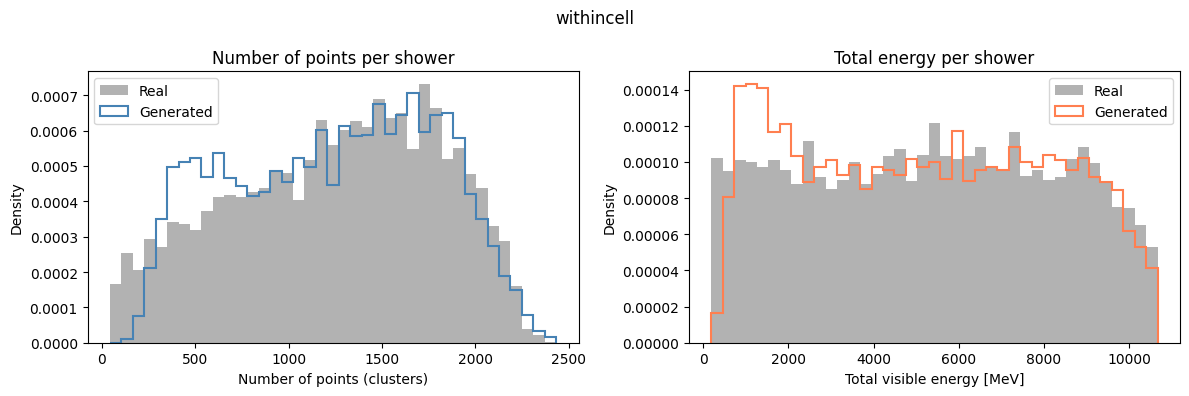

In [ ]:
gen_n_hits  = gen_mask.sum(axis=1)
real_n_hits = real_mask.sum(axis=1)
gen_e_sum   = (fake_showers[:, :, 3] * gen_mask).sum(axis=1)
real_e_sum  = (real_events[:, :, 3] * real_mask).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lo = min(gen_n_hits.min(), real_n_hits.min())
hi = max(gen_n_hits.max(), real_n_hits.max())
bins = np.linspace(lo, hi, 40)
axes[0].hist(real_n_hits, bins=bins, density=True, histtype='stepfilled',
             color='grey', alpha=0.6, label='Real')
axes[0].hist(gen_n_hits,  bins=bins, density=True, histtype='step',
             color='steelblue', linewidth=1.5, label='Generated')
axes[0].set_xlabel('Number of points (clusters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Number of points per shower')
axes[0].legend()

lo = min(np.percentile(gen_e_sum, 1), np.percentile(real_e_sum, 1))
hi = max(np.percentile(gen_e_sum, 99), np.percentile(real_e_sum, 99))
bins = np.linspace(lo, hi, 40)
axes[1].hist(real_e_sum, bins=bins, density=True, histtype='stepfilled',
             color='grey', alpha=0.6, label='Real')
axes[1].hist(gen_e_sum,  bins=bins, density=True, histtype='step',
             color='coral', linewidth=1.5, label='Generated')
axes[1].set_xlabel('Total visible energy [MeV]')
axes[1].set_ylabel('Density')
axes[1].set_title('Total energy per shower')
axes[1].legend()
plt.suptitle(data_used)
plt.tight_layout()
plt.show()

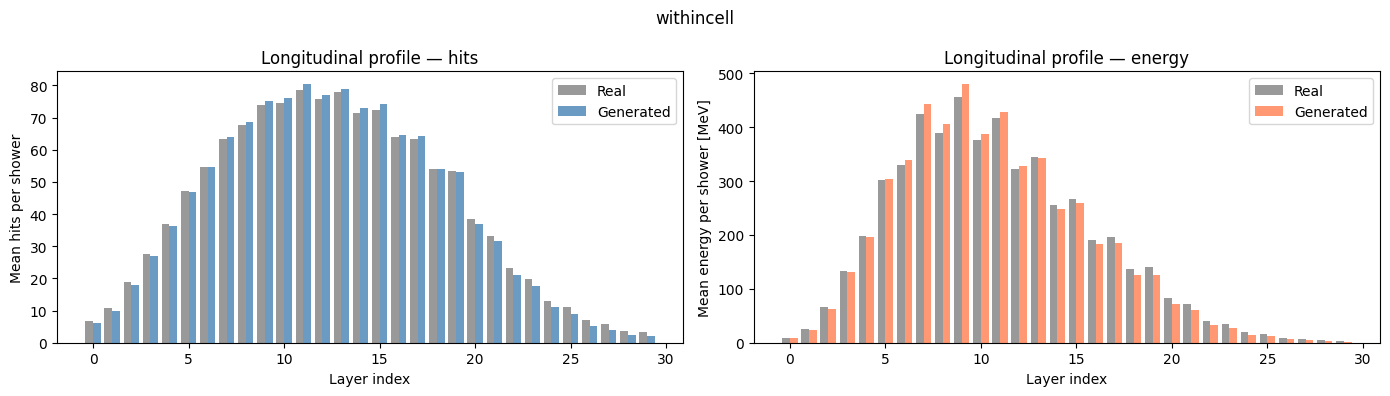

In [ ]:
# Longitudinal profile: hits and energy per layer — generated vs real
# Real z ≈ layer index [0,29]; generated z is in global mm → use global layer bounds.
floors_hdf5, ceilings_hdf5 = floors_ceilings(meta.layer_bottom_pos_hdf5, meta.cell_thickness_hdf5)
floors_glob, ceilings_glob = floors_ceilings(meta.layer_bottom_pos_global, meta.cell_thickness_global)
n_layers = len(floors_hdf5)
layer_idx = np.arange(n_layers)

gen_hits_layer  = np.zeros(n_layers)
real_hits_layer = np.zeros(n_layers)
gen_e_layer     = np.zeros(n_layers)
real_e_layer    = np.zeros(n_layers)

for i, (fh, ch, fg, cg) in enumerate(zip(floors_hdf5, ceilings_hdf5, floors_glob, ceilings_glob)):
    real_in = (real_events[:, :, 2] >= fh) & (real_events[:, :, 2] < ch) & real_mask
    gen_in  = (fake_showers[:, :, 2] >= fg) & (fake_showers[:, :, 2] < cg) & gen_mask
    real_hits_layer[i] = real_in.sum()
    gen_hits_layer[i]  = gen_in.sum()
    real_e_layer[i]    = real_events[:, :, 3][real_in].sum()
    gen_e_layer[i]     = fake_showers[:, :, 3][gen_in].sum()

gen_hits_layer  /= n_showers
real_hits_layer /= len(real_events)
gen_e_layer     /= n_showers
real_e_layer    /= len(real_events)

width = 0.4
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(layer_idx - width/2, real_hits_layer, width, label='Real',      color='grey', alpha=0.8)
axes[0].bar(layer_idx + width/2, gen_hits_layer,  width, label='Generated', color='steelblue', alpha=0.8)
axes[0].set_xlabel('Layer index')
axes[0].set_ylabel('Mean hits per shower')
axes[0].set_title('Longitudinal profile — hits')
axes[0].legend()

axes[1].bar(layer_idx - width/2, real_e_layer, width, label='Real',      color='grey', alpha=0.8)
axes[1].bar(layer_idx + width/2, gen_e_layer,  width, label='Generated', color='coral', alpha=0.8)
axes[1].set_xlabel('Layer index')
axes[1].set_ylabel('Mean energy per shower [MeV]')
axes[1].set_title('Longitudinal profile — energy')
axes[1].legend()
plt.suptitle(data_used)
plt.tight_layout()
plt.show()

## Center of gravity and radial profile

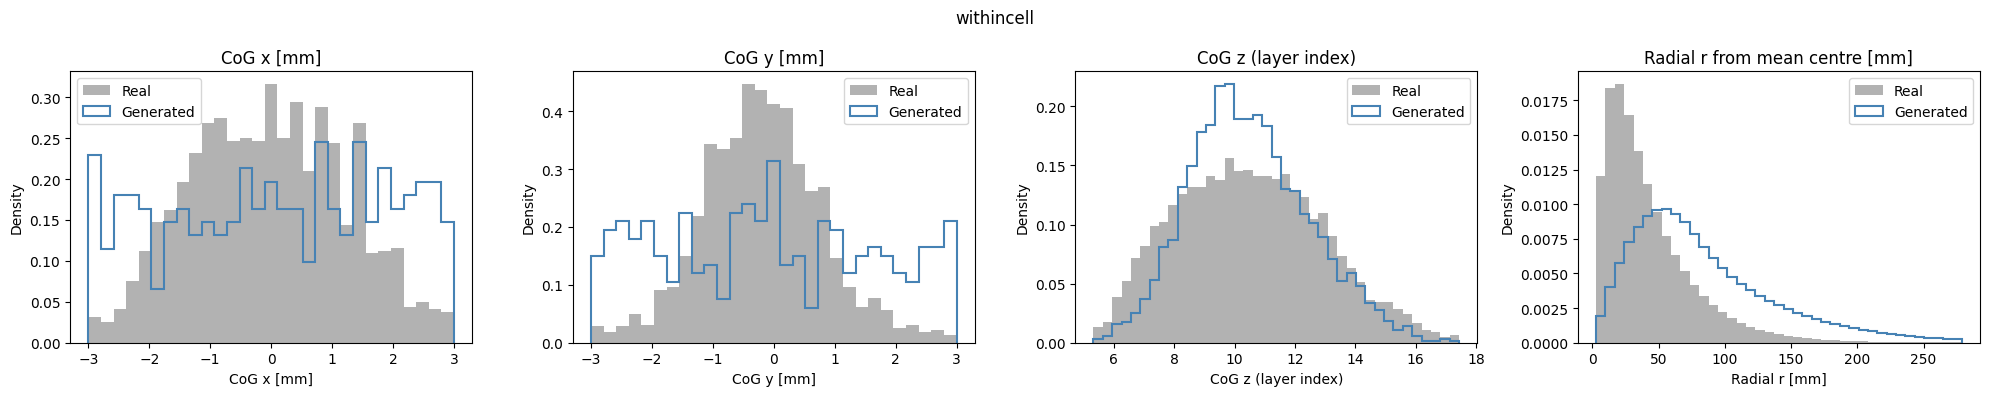

In [ ]:
# Energy-weighted center of gravity per shower and radial spread
# gen_z_layer / real_z_layer already computed in cell-plot-coords (layer index, float)

def _e_cog(arr, energy, mask):
    e = energy * mask
    a = arr * mask
    return (a * e).sum(axis=1) / e.sum(axis=1)

def _mean_center(arr, mask):
    return (arr * mask).sum(axis=1) / mask.sum(axis=1)

gen_cog_x = _e_cog(fake_showers[:, :, 0], fake_showers[:, :, 3], gen_mask)
gen_cog_y = _e_cog(fake_showers[:, :, 1], fake_showers[:, :, 3], gen_mask)
gen_cog_z = _e_cog(gen_z_layer.astype(float), fake_showers[:, :, 3], gen_mask)

real_cog_x = _e_cog(real_events[:, :, 0], real_events[:, :, 3], real_mask)
real_cog_y = _e_cog(real_events[:, :, 1], real_events[:, :, 3], real_mask)
real_cog_z = _e_cog(real_z_layer.astype(float), real_events[:, :, 3], real_mask)

# Simple mean center per shower (for radial distribution)
gen_mean_x  = _mean_center(fake_showers[:, :, 0], gen_mask)
gen_mean_y  = _mean_center(fake_showers[:, :, 1], gen_mask)
real_mean_x = _mean_center(real_events[:, :, 0], real_mask)
real_mean_y = _mean_center(real_events[:, :, 1], real_mask)

# Radial distance of each hit from its shower's geometric mean transverse centre
gen_r  = np.sqrt((fake_showers[:, :, 0] - gen_mean_x[:, None])**2 +
                 (fake_showers[:, :, 1] - gen_mean_y[:, None])**2)
real_r = np.sqrt((real_events[:, :, 0] - real_mean_x[:, None])**2 +
                 (real_events[:, :, 1] - real_mean_y[:, None])**2)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
pairs = [
    ('CoG x [mm]',          gen_cog_x,        real_cog_x),
    ('CoG y [mm]',          gen_cog_y,        real_cog_y),
    ('CoG z (layer index)', gen_cog_z,        real_cog_z),
    ('Radial r [mm]',       gen_r[gen_mask],  real_r[real_mask]),
]
for j, (ax, (label, gv, rv)) in enumerate(zip(axes, pairs)):
    lo = min(np.percentile(gv, 1), np.percentile(rv, 1))
    hi = max(np.percentile(gv, 99), np.percentile(rv, 99))
    bins = np.linspace(lo, hi, 40) if j>1 else np.linspace(-3, 3, 30) 
    ax.hist(rv, bins=bins, density=True, histtype='stepfilled', color='grey', alpha=0.6, label='Real')
    ax.hist(gv, bins=bins, density=True, histtype='step', color='steelblue', lw=1.5, label='Generated')
    ax.set_xlabel(label); ax.set_ylabel('Density'); ax.legend(); ax.set_title(label)
axes[3].set_title('Radial r from mean centre [mm]')
plt.suptitle(data_used)
plt.tight_layout(); plt.show()

## Longitudinal profiles at different incident energies

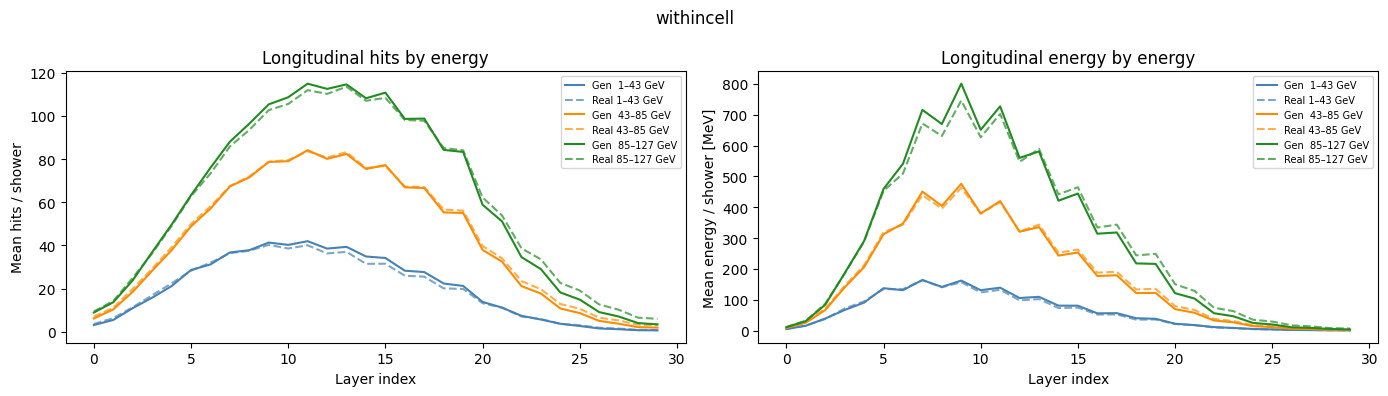

In [ ]:
# cond[:, 0] is the raw incident energy in GeV (normalized by incident_rescale inside gen_cond_showers_batch)
inc_energy = cond[:, 0].numpy()
e_edges = np.percentile(inc_energy, [0, 33, 67, 100])
e_labels = [f'{e_edges[i]:.0f}–{e_edges[i+1]:.0f} GeV' for i in range(3)]
colors = ['steelblue', 'darkorange', 'forestgreen']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i in range(3):
    sel = (inc_energy >= e_edges[i]) & (inc_energy <= e_edges[i + 1])
    n_sel = sel.sum()

    hits_gen = np.zeros(n_layers)
    e_gen    = np.zeros(n_layers)
    hits_real = np.zeros(n_layers)
    e_real    = np.zeros(n_layers)
    for li, (fh, ch, fg, cg) in enumerate(zip(floors_hdf5, ceilings_hdf5, floors_glob, ceilings_glob)):
        in_g = (fake_showers[sel, :, 2] >= fg) & (fake_showers[sel, :, 2] < cg) & gen_mask[sel]
        in_r = (real_events[sel, :, 2] >= fh) & (real_events[sel, :, 2] < ch) & real_mask[sel]
        hits_gen[li]  = in_g.sum() / (n_sel + 1e-12)
        e_gen[li]     = fake_showers[sel, :, 3][in_g].sum() / (n_sel + 1e-12)
        hits_real[li] = in_r.sum() / (n_sel + 1e-12)
        e_real[li]    = real_events[sel, :, 3][in_r].sum() / (n_sel + 1e-12)

    axes[0].plot(layer_idx, hits_gen,  color=colors[i], lw=1.5,             label=f'Gen  {e_labels[i]}')
    axes[0].plot(layer_idx, hits_real, color=colors[i], lw=1.5, ls='--', alpha=0.7, label=f'Real {e_labels[i]}')
    axes[1].plot(layer_idx, e_gen,  color=colors[i], lw=1.5,             label=f'Gen  {e_labels[i]}')
    axes[1].plot(layer_idx, e_real, color=colors[i], lw=1.5, ls='--', alpha=0.7, label=f'Real {e_labels[i]}')

for ax, title, ylabel in zip(axes,
        ['Longitudinal hits by energy', 'Longitudinal energy by energy'],
        ['Mean hits / shower', 'Mean energy / shower [MeV]']):
    ax.set_xlabel('Layer index'); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=7)
plt.suptitle(data_used)
plt.tight_layout(); plt.show()

## Longitudinal profiles at different incident angles

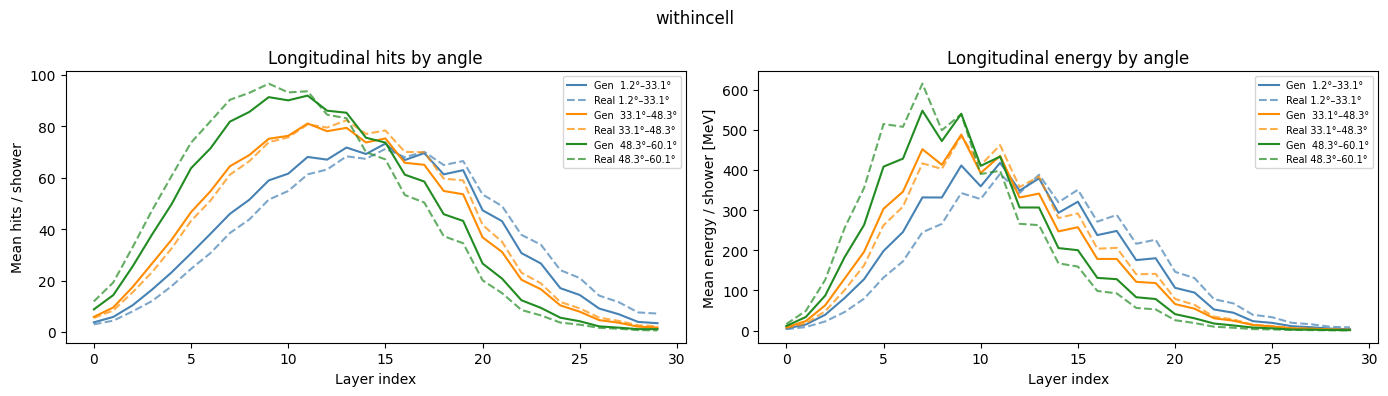

In [ ]:
# Angle of beam from local z-axis: theta = arccos(|pz_local|)
# cond[:, 1:4] is p_norm_local (unit vector); column 3 is the z-component
pz_local   = cond[:, 3].numpy()
theta_deg  = np.degrees(np.arccos(np.clip(np.abs(pz_local), 0, 1)))
th_edges   = np.percentile(theta_deg, [0, 33, 67, 100])
th_labels  = [f'{th_edges[i]:.1f}°–{th_edges[i+1]:.1f}°' for i in range(3)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i in range(3):
    sel   = (theta_deg >= th_edges[i]) & (theta_deg <= th_edges[i + 1])
    n_sel = sel.sum()

    hits_gen  = np.zeros(n_layers)
    e_gen     = np.zeros(n_layers)
    hits_real = np.zeros(n_layers)
    e_real    = np.zeros(n_layers)
    for li, (fh, ch, fg, cg) in enumerate(zip(floors_hdf5, ceilings_hdf5, floors_glob, ceilings_glob)):
        in_g = (fake_showers[sel, :, 2] >= fg) & (fake_showers[sel, :, 2] < cg) & gen_mask[sel]
        in_r = (real_events[sel, :, 2] >= fh) & (real_events[sel, :, 2] < ch) & real_mask[sel]
        hits_gen[li]  = in_g.sum() / (n_sel + 1e-12)
        e_gen[li]     = fake_showers[sel, :, 3][in_g].sum() / (n_sel + 1e-12)
        hits_real[li] = in_r.sum() / (n_sel + 1e-12)
        e_real[li]    = real_events[sel, :, 3][in_r].sum() / (n_sel + 1e-12)

    axes[0].plot(layer_idx, hits_gen,  color=colors[i], lw=1.5,             label=f'Gen  {th_labels[i]}')
    axes[0].plot(layer_idx, hits_real, color=colors[i], lw=1.5, ls='--', alpha=0.7, label=f'Real {th_labels[i]}')
    axes[1].plot(layer_idx, e_gen,  color=colors[i], lw=1.5,             label=f'Gen  {th_labels[i]}')
    axes[1].plot(layer_idx, e_real, color=colors[i], lw=1.5, ls='--', alpha=0.7, label=f'Real {th_labels[i]}')

for ax, title, ylabel in zip(axes,
        ['Longitudinal hits by angle', 'Longitudinal energy by angle'],
        ['Mean hits / shower', 'Mean energy / shower [MeV]']):
    ax.set_xlabel('Layer index'); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=7)
plt.suptitle(data_used)
plt.tight_layout(); plt.show()

In [ ]:
import os
save_path = os.path.join(os.path.dirname(model_path), "generated_showers.npz")
np.savez(save_path, showers=fake_showers, cond=cond.numpy())
print(f"Saved → {save_path}")

Saved → /eos/user/m/mamozzan/CaloClouds-3/log_dir/CD_S2P_WithinCell_2026_06_10__15_05_47/generated_showers.npz
